<a href="https://colab.research.google.com/github/emiliomercuri/EnvHydrology2026/blob/main/Aulas/Aula_17-Sep_fluxo_base/Separac%CC%A7a%CC%83o_do_Fluxo_de_Base_Me%CC%81todo_de_Hewlett_and_Hibbert_(1967).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Separação do Fluxo de Base

Utilizando o Método de Hewlett and Hibbert (1967)

Um método empírico amplamente utilizado para pequenas bacias foi proposto por Hewlett e Hibbert (1967) que argumentaram que “uma vez que uma separação arbitrária deve ser feita em qualquer caso, por que não basear a classificação em uma única decisão arbitrária, como um método fixo e universal? para separar hidrogramas em todas as pequenas bacias?” Eles separaram o hidrograma em componentes de "fluxo rápido" e "fluxo lento", projetando arbitrariamente uma linha de inclinação constante desde o início de qualquer aumento de vazão até cruzar a curva de recessão do hidrograma.

O aumento constante da vazão é descrito pelas equações:
\begin{equation}
\begin{aligned}
&B_{t}=B_{t-1}+ k \, \Delta t \, A \text { para } Q_{t}>B_{t-1}+k \, \Delta t \, A, \\
&B_{t}=Q_{t} \text { para } Q_{t} \leq B_{t-1} + k \, \Delta t \, A.
\end{aligned}
\end{equation}

Sendo que $k$ determina a inclinação da reta ($k = 0,000546$ m$^3$s$^{-1}$km$^{-2}$h$^{-1}$) ponderada pela área da bacia $A$ em km$^2$ e pelo intervalo de tempo $\Delta t$ em horas (Hewlet e Hibbert, 1967).

In [1]:
pip install Hydrograph-py

  Preparing metadata (setup.py) ... done
  Created wheel for Hydrograph-py: filename=Hydrograph_py-1.0.1-py3-none-any.whl size=11194 sha256=1d477df2af1642bd4b53bb77d4118bc1a863dae37999bc253b1ab4a8b62a1412
  Stored in directory: /root/.cache/pip/wheels/a9/e5/7a/c4e22421d45ad221f05f6c7ddf97992a810c54dd6d18ed324e
Successfully built Hydrograph-py


In [2]:
from Hydrograph.hydrograph import sepBaseflow

In [3]:
import pandas
from datetime import datetime

In [4]:
from urllib.request import urlretrieve
URL = 'https://www.dropbox.com/s/0izm52b1ofqlbn3/vazao%20nhundi%2082170000%20-%20menor.csv?dl=1'
urlretrieve(URL, 'vazao diaria.csv')

('vazao diaria.csv', <http.client.HTTPMessage at 0x7b45a87fd100>)

In [5]:
timestamp_format = '%d/%m/%Y'
vazao = pandas.read_csv('vazao diaria.csv', index_col= 0, sep =';', date_format=timestamp_format,parse_dates=['Date'], names=['Date', 'Total runoff [m^3 s^-1]'], header=0)

In [6]:
vazao

,Total runoff [m^3 s^-1]
Date,
1939-01-01,10.56
1939-01-02,8.19
1939-01-03,16.16
1939-01-04,16.69
1939-01-05,15.11
...,...
1939-03-27,17.76
1939-03-28,14.59
1939-03-29,11.05


<Axes: xlabel='Date'>

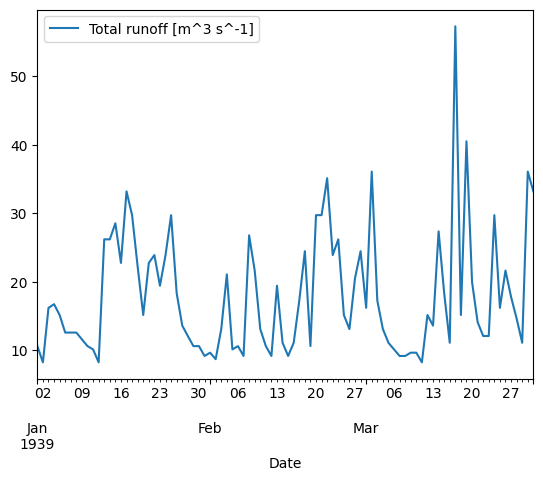

In [7]:
vazao.plot()

In [13]:
sepBaseflow?

## Função sepBaseflow

Nessa função vamos informar 3 argumentos:

1. Dataframe com os dados diários de vazão
2. $\Delta t$ para interpolação dos dados diários em horários ($\Delta t = 60$ min = 1 hora)
3. Área da bacia em km$^2$

O algoritmo faz a separação do fluxo de base usando as equações mostradas no início do notebook.

In [9]:
df_final = sepBaseflow(vazao,60,100)

Processing using a 60-minute interval...
1939-01-01 00:00:00
1939-01-01 01:00:00
1939-01-01 02:00:00
1939-01-01 03:00:00
1939-01-01 04:00:00
1939-01-01 05:00:00
1939-01-01 06:00:00
1939-01-01 07:00:00
1939-01-01 08:00:00
1939-01-01 09:00:00
1939-01-01 10:00:00
1939-01-01 11:00:00
1939-01-01 12:00:00
1939-01-01 13:00:00
1939-01-01 14:00:00
1939-01-01 15:00:00
1939-01-01 16:00:00
1939-01-01 17:00:00
1939-01-01 18:00:00
1939-01-01 19:00:00
1939-01-01 20:00:00
1939-01-01 21:00:00
1939-01-01 22:00:00
1939-01-01 23:00:00
1939-01-02 00:00:00
1939-01-02 01:00:00
1939-01-02 02:00:00
1939-01-02 03:00:00
1939-01-02 04:00:00
1939-01-02 05:00:00
1939-01-02 06:00:00
1939-01-02 07:00:00
1939-01-02 08:00:00
1939-01-02 09:00:00
1939-01-02 10:00:00
1939-01-02 11:00:00
1939-01-02 12:00:00
1939-01-02 13:00:00
1939-01-02 14:00:00
1939-01-02 15:00:00
1939-01-02 16:00:00
1939-01-02 17:00:00
1939-01-02 18:00:00
1939-01-02 19:00:00
1939-01-02 20:00:00
1939-01-02 21:00:00
1939-01-02 22:00:00
1939-01-02 23:00:00

/usr/local/lib/python3.12/dist-packages/Hydrograph/hydrograph.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dr = pd.date_range(minDate, maxDate, freq='60T')  #-60-minute interval


1939-01-09 01:00:00
1939-01-09 02:00:00
1939-01-09 03:00:00
1939-01-09 04:00:00
1939-01-09 05:00:00
1939-01-09 06:00:00
1939-01-09 07:00:00
1939-01-09 08:00:00
1939-01-09 09:00:00
1939-01-09 10:00:00
1939-01-09 11:00:00
1939-01-09 12:00:00
1939-01-09 13:00:00
1939-01-09 14:00:00
1939-01-09 15:00:00
1939-01-09 16:00:00
1939-01-09 17:00:00
1939-01-09 18:00:00
1939-01-09 19:00:00
1939-01-09 20:00:00
1939-01-09 21:00:00
1939-01-09 22:00:00
1939-01-09 23:00:00
1939-01-10 00:00:00
1939-01-10 01:00:00
1939-01-10 02:00:00
1939-01-10 03:00:00
1939-01-10 04:00:00
1939-01-10 05:00:00
1939-01-10 06:00:00
1939-01-10 07:00:00
1939-01-10 08:00:00
1939-01-10 09:00:00
1939-01-10 10:00:00
1939-01-10 11:00:00
1939-01-10 12:00:00
1939-01-10 13:00:00
1939-01-10 14:00:00
1939-01-10 15:00:00
1939-01-10 16:00:00
1939-01-10 17:00:00
1939-01-10 18:00:00
1939-01-10 19:00:00
1939-01-10 20:00:00
1939-01-10 21:00:00
1939-01-10 22:00:00
1939-01-10 23:00:00
1939-01-11 00:00:00
1939-01-11 01:00:00
1939-01-11 02:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1939-01-26 12:00:00
1939-01-26 13:00:00
1939-01-26 14:00:00
1939-01-26 15:00:00
1939-01-26 16:00:00
1939-01-26 17:00:00
1939-01-26 18:00:00
1939-01-26 19:00:00
1939-01-26 20:00:00
1939-01-26 21:00:00
1939-01-26 22:00:00
1939-01-26 23:00:00
1939-01-27 00:00:00
1939-01-27 01:00:00
1939-01-27 02:00:00
1939-01-27 03:00:00
1939-01-27 04:00:00
1939-01-27 05:00:00
1939-01-27 06:00:00
1939-01-27 07:00:00
1939-01-27 08:00:00
1939-01-27 09:00:00
1939-01-27 10:00:00
1939-01-27 11:00:00
1939-01-27 12:00:00
1939-01-27 13:00:00
1939-01-27 14:00:00
1939-01-27 15:00:00
1939-01-27 16:00:00
1939-01-27 17:00:00
1939-01-27 18:00:00
1939-01-27 19:00:00
1939-01-27 20:00:00
1939-01-27 21:00:00
1939-01-27 22:00:00
1939-01-27 23:00:00
1939-01-28 00:00:00
1939-01-28 01:00:00
1939-01-28 02:00:00
1939-01-28 03:00:00
1939-01-28 04:00:00
1939-01-28 05:00:00
1939-01-28 06:00:00
1939-01-28 07:00:00
1939-01-28 08:00:00
1939-01-28 09:00:00
1939-01-28 10:00:00
1939-01-28 11:00:00
1939-01-28 12:00:00
1939-01-28 13:00:00


/usr/local/lib/python3.12/dist-packages/Hydrograph/hydrograph.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NaT' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_final.loc[df_final['Peak nr.'] ==i, 'Date max. flow'] = mdate


In [10]:
df_final

,dt [hour],Total runoff [m^3 s^-1],Total runoff interp. [m^3 s^-1],Baseflow [m^3 s^-1],Peakflow [m^3 s^-1],Peak nr.,Peakflow starts,Peakflow ends,Flow volume [m^3],Max. flow [m^3 s^-1],Date max. flow,Tp [hour]
Date,,,,,,,,,,,,
1939-01-01 00:00:00,0.0,10.56,10.560000,10.56000,0.000000,NaN,NaT,NaT,NaN,NaN,NaT,NaN
1939-01-01 01:00:00,1.0,NaN,10.461250,10.46125,0.000000,NaN,NaT,NaT,NaN,NaN,NaT,NaN
1939-01-01 02:00:00,1.0,NaN,10.362500,10.36250,0.000000,NaN,NaT,NaT,NaN,NaN,NaT,NaN
1939-01-01 03:00:00,1.0,NaN,10.263750,10.26375,0.000000,NaN,NaT,NaT,NaN,NaN,NaT,NaN
1939-01-01 04:00:00,1.0,NaN,10.165000,10.16500,0.000000,NaN,NaT,NaT,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1939-03-30 20:00:00,1.0,NaN,33.671667,13.45240,20.219267,14.0,1939-03-29 01:00:00,1939-03-31,121218.0,36.08,1939-03-30,23.0
1939-03-30 21:00:00,1.0,NaN,33.551250,13.50700,20.044250,14.0,1939-03-29 01:00:00,1939-03-31,120784.5,36.08,1939-03-30,23.0
1939-03-30 22:00:00,1.0,NaN,33.430833,13.56160,19.869233,14.0,1939-03-29 01:00:00,1939-03-31,120351.0,36.08,1939-03-30,23.0


In [11]:
from matplotlib import pyplot as plt
import numpy
import matplotlib.dates as mdates
from datetime import datetime, timedelta

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

<Figure size 640x480 with 0 Axes>

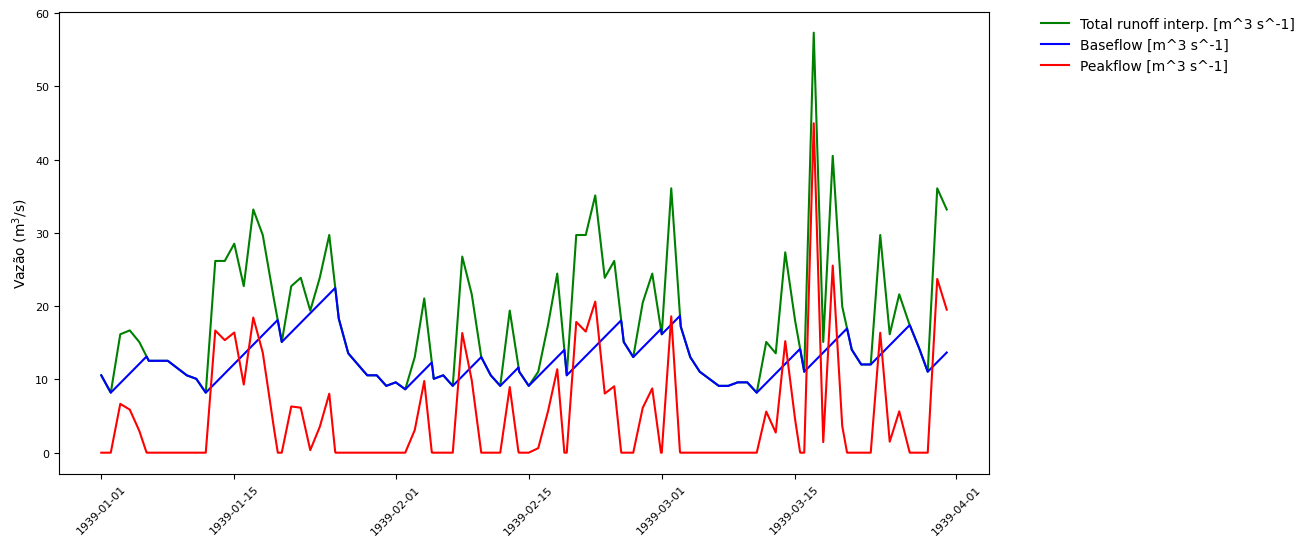

In [12]:
plt.gcf().autofmt_xdate()
plt.figure(figsize=(12, 6))
#plt.plot(df_final['Total runoff [m^3 s^-1]'],color='green', marker='o', linestyle='dashed',linewidth=1.5, markersize=1.1, label = 'Vazão (m3/s)')
plt.plot(df_final['Total runoff interp. [m^3 s^-1]'],color='green', linewidth=1.5, markersize=1.1, label = 'Total runoff interp. [m^3 s^-1]')
plt.plot(df_final['Baseflow [m^3 s^-1]'],color='blue',linewidth=1.5, markersize=1.1, label = 'Baseflow [m^3 s^-1]')
plt.plot(df_final['Peakflow [m^3 s^-1]'],color='red',linewidth=1.5, markersize=1.1, label = 'Peakflow [m^3 s^-1]')
plt.ylabel(r'Vazão (m$^3$/s)')

plt.tick_params(axis='both', labelsize=8) #increase font size for ticks
plt.xticks(rotation=45)
leg = plt.legend();
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,frameon=False)

plt.show()